In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
plt.rcParams.update({
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'axes.titlesize': 18,
    'font.size': 18,
    'lines.linewidth': 1.5,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral'
})

In [3]:
def compute_parameters(p_star, S1, S2, total_N, a11=0.1, a22=0.1):
    N1_star = p_star * total_N
    N2_star = (1 - p_star) * total_N
    r1 = (1 + a11 * total_N) / (1 + S1 * N2_star / total_N)
    r2 = (1 + a22 * total_N) / (1 + S2 * N1_star / total_N)
    a12 = a11 - S1 * r1 / total_N
    a21 = a22 - S2 * r2 / total_N
    return r1, r2, a11, a22, a12, a21

In [4]:
def plot_panel(ax, S1, S2, p_star, label_m):
    x1 = np.linspace(0, 1, 200)
    y1 = -S1 * (x1 - p_star)
    ax.plot(x1, y1, 'k-', label='Species 1')
    x2 = np.linspace(0, 1, 200)
    y2 = -S2 * (x2 - (1 - p_star))
    ax.plot(x2, y2, 'k--', label='Species 2')
    ax.axhline(0, color='gray', linestyle=':')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('log(growth rate)')
    ax.legend(loc='lower left')
    ax.text(0.8, 0.9, label_m, transform=ax.transAxes, ha='center')

In [5]:
def main():
    p_star = 0.2
    total_N = 1000.0
    a11 = 0.1
    a22 = 0.1
    scenarios = [
        (0.5, 1.5, '(a) nu > 0'),
        (1.0, 1.0, '(b) nu \u2248 0'),
        (1.5, 0.5, '(c) nu < 0')
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (S1, S2, label_m) in zip(axes, scenarios):
        params = compute_parameters(p_star, S1, S2, total_N, a11, a22)
        r1, r2, a11_val, a22_val, a12, a21 = params
        case = label_m[:3]
        r1m1 = r1 - 1.0
        r2m1 = r2 - 1.0
        thresh12 = a22_val * r1m1 / r2m1 if r2m1 != 0 else float('inf')
        thresh21 = a11_val * r2m1 / r1m1 if r1m1 != 0 else float('inf')
        eps = 1e-9
        if a12 < thresh12 - eps and a21 > thresh21 + eps:
            regime = "competitive exclusion (N1 excludes N2)"
        elif a21 < thresh21 - eps and a12 > thresh12 + eps:
            regime = "competitive exclusion (N2 excludes N1)"
        elif a12 < thresh12 - eps and a21 < thresh21 - eps:
            regime = "coexistence"
        elif a12 > thresh12 + eps and a21 > thresh21 + eps:
            regime = "saddle node"
        elif abs(a12 - thresh12) < eps and abs(a21 - thresh21) < eps:
            regime = "borderline"
        else:
            regime = "undefined"
        print(f"Case: {case} r1={r1:.3g} r2={r2:.3g} a11={a11_val:.3g} a22={a22_val:.3g} a12={a12:.3g} a21={a21:.3g} regime: {regime}")
        plot_panel(ax, S1, S2, p_star, label_m)
        ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

Case: (a) r1=72.1 r2=77.7 a11=0.1 a22=0.1 a12=0.0639 a21=-0.0165 regime: coexistence
Case: (b) r1=56.1 r2=84.2 a11=0.1 a22=0.1 a12=0.0439 a21=0.0158 regime: coexistence
Case: (c) r1=45.9 r2=91.8 a11=0.1 a22=0.1 a12=0.0311 a21=0.0541 regime: coexistence


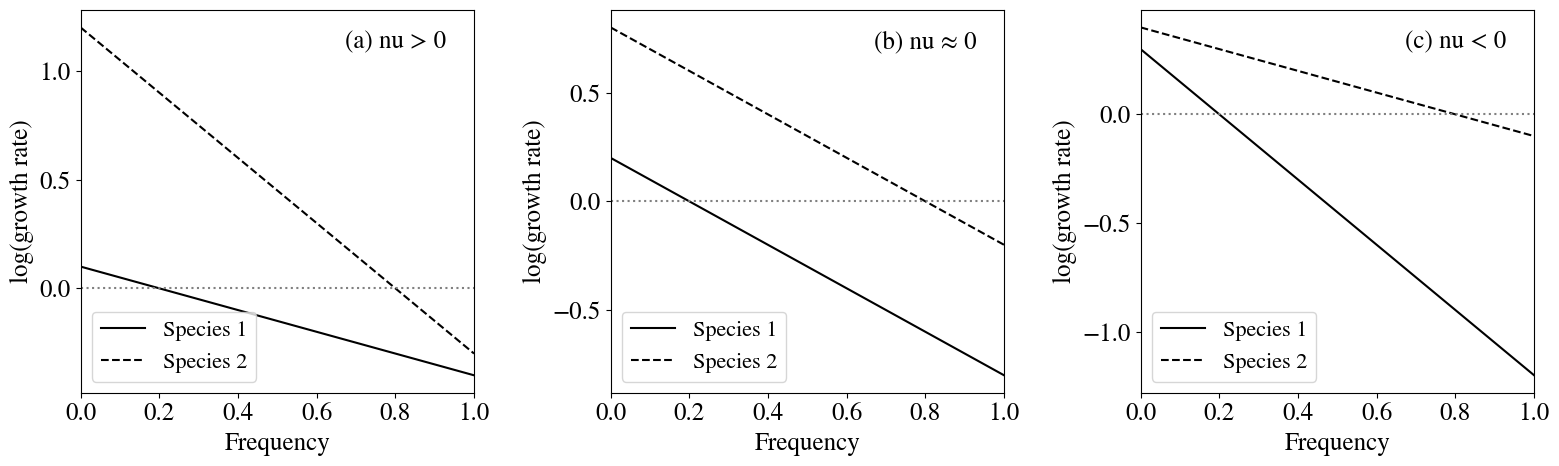

In [6]:
if __name__ == "__main__":
    main()